In [1]:
import sys
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.annealer import QuantumAnnealer

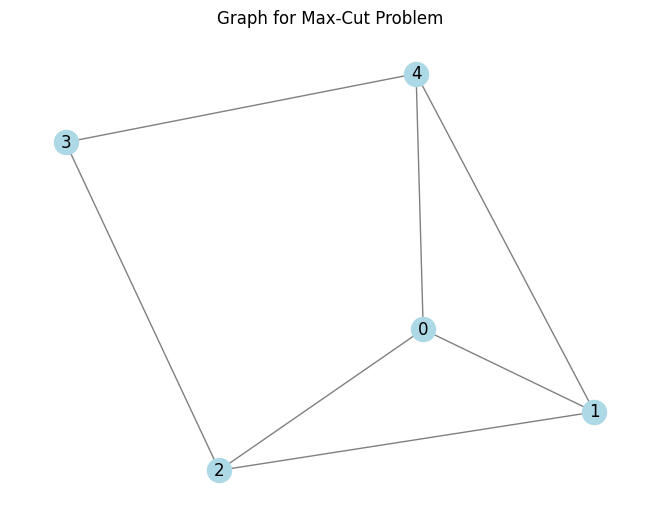

In [2]:
graph = nx.Graph()
graph.add_nodes_from([0, 1, 2, 3, 4])
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2), (1, 4)]
graph.add_edges_from(edges)

pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Graph for Max-Cut Problem")
plt.show()

In [3]:
annealer = QuantumAnnealer(graph)
solution_str = annealer.anneal(total_time=10, time_steps=200)
cut_count, partition = annealer.get_max_cut_solution(solution_str)

print("--- Results ---")
print(f"Optimal solution found: {solution_str}")
print(f"Node partition sets: {partition}")
print(f"Number of edges cut: {cut_count}")


--- Results ---
Optimal solution found: 11010
Node partition sets: ([2, 4], [0, 1, 3])
Number of edges cut: 6


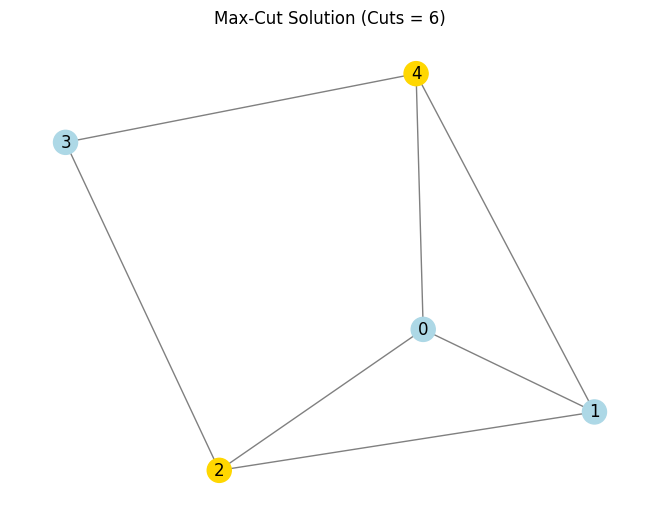

In [4]:
colors = ['gold' if bit == '0' else 'lightblue' for bit in solution_str]
nx.draw(graph, pos, with_labels=True, node_color=colors, edge_color='gray')
plt.title(f"Max-Cut Solution (Cuts = {cut_count})")
plt.show()